In [2]:
"""
Unit 5: Evolving Your IPD Agent with Genetic Algorithms
========================================================

In Unit 4, you hand-coded agent strategies like Tit-for-Tat.
In Unit 5, you'll use evolution to DISCOVER strategies automatically.

By the end, you'll have an evolved agent saved as a JSON file for the tournament!
"""

# ============================================================================
# SETUP: Import everything from previous units
# ============================================================================

import random
import numpy as np
import json
import matplotlib.pyplot as plt
from agents import Agent, INVEST, UNDERCUT
from game_engine import Game, Tournament

# Import all hand-coded agents from Unit 4
from agents import (
    AlwaysInvestAgent, AlwaysUndercutAgent, TitForTatAgent,
    GrimTriggerAgent, PavlovAgent, TitForTwoTatsAgent,
    GenerousTitForTatAgent, AdaptiveAgent, RandomAgent,
    SuspiciousTitForTatAgent, GradualAgent, HardMajorityAgent,
    SoftMajorityAgent, ProberAgent
)

print("✅ Imports complete!")

✅ Imports complete!


In [4]:

# ============================================================================
# PART 1: THE EVOLVABLE AGENT (PROVIDED - Read but don't modify)
# ============================================================================

class EvolvableAgent(Agent):
    """
    An agent whose strategy is controlled by 6 genes (numbers from 0 to 1).
    
    Think of genes as "strategy dials" you can tune:
    
    Gene[0] - Initial Cooperation (0=hostile start, 1=friendly start)
    Gene[1] - Cooperation Response (if opponent cooperates, how likely to cooperate back?)
    Gene[2] - Defection Response (if opponent defects, how likely to defect back?)
    Gene[3] - Forgiveness (after retaliation, chance to forgive)
    Gene[4] - Memory Length (0=last 1 round, 1=last 10 rounds)
    Gene[5] - Retaliation Threshold (what % of defections triggers retaliation)
    """
    
    def __init__(self, genes=None, name="Evolved Agent"):
        if genes is None:
            # Create random genes if none provided
            genes = [random.random() for _ in range(6)]
        
        self.genes = genes
        super().__init__(name, f"Genes: [{', '.join([f'{g:.2f}' for g in genes])}]")
    
    def choose_action(self) -> bool:
        """Decision logic based on genes - SIMPLIFIED FOR LEARNING"""
        
        # First 3 rounds: use initial cooperation gene
        if self.round_num < 3:
            return random.random() < self.genes[0]
        
        # Calculate memory window (gene[4])
        memory_length = max(1, int(self.genes[4] * 10) + 1)
        recent_history = self.history[-memory_length:]
        
        # Calculate opponent's recent COOPERATION rate (not defection!)
        cooperation_rate = sum(recent_history) / len(recent_history)
        
        # If opponent is mostly cooperating, reciprocate
        if cooperation_rate >= 0.5:
            return random.random() < self.genes[1]  # gene[1] = cooperate response
        
        # If opponent is mostly defecting, retaliate or forgive
        else:
            # Retaliate with probability gene[2]
            if random.random() < self.genes[2]:
                return UNDERCUT
            # Or forgive with probability gene[3]
            elif random.random() < self.genes[3]:
                return INVEST
            else:
                return UNDERCUT


In [8]:

# ============================================================================
# PART 2: DEFINE THE OPPONENT ECOSYSTEM
# ============================================================================

# ============================================================================
# EXPANDED OPPONENT POOL
# ============================================================================

# Full pool of all possible opponents
full_opponent_pool = [
    # Cooperative agents
    AlwaysInvestAgent(),
    TitForTatAgent(),
    GrimTriggerAgent(),
    PavlovAgent(),
    TitForTwoTatsAgent(),
    GenerousTitForTatAgent(),
    AdaptiveAgent(),
    
    # Aggressive agents
    AlwaysUndercutAgent(),
    SuspiciousTitForTatAgent(),
    
    # Sophisticated agents
    GradualAgent(),
    ProberAgent(),
    
    # Majority-based agents
    HardMajorityAgent(),
    SoftMajorityAgent(),
    
    # Random agents with different cooperation levels
    RandomAgent(0.9),
    RandomAgent(0.7),
    RandomAgent(0.5),
    RandomAgent(0.3),
    RandomAgent(0.1),
]

print(f"\n📚 Full opponent library: {len(full_opponent_pool)} agents available")

# For initial evolution, randomly sample opponents
opponent_pool = random.sample(full_opponent_pool, 10)

print(f"🎲 Randomly selected {len(opponent_pool)} opponents for this evolution:")
for i, opp in enumerate(opponent_pool, 1):
    print(f"  {i:2d}. {opp.name:25s} - {opp.description}")
print("="*70)




📚 Full opponent library: 18 agents available
🎲 Randomly selected 10 opponents for this evolution:
   1. Suspicious Tit-for-Tat    - Starts hostile, then copies opponent
   2. Soft Majority             - Cooperates if opponent cooperates >=50% of time
   3. Hard Majority             - Defects if opponent defects >50% of time
   4. Pavlov                    - Win-Stay-Lose-Shift strategy
   5. Gradual                   - Escalates punishment after each betrayal
   6. Tit-for-Tat               - Starts friendly, then copies opponent
   7. Always Invest             - Always invests in market development
   8. Generous Tit-for-Tat      - Tit-for-Tat with 10% forgiveness
   9. Tit-for-Two-Tats          - Tolerates one betrayal, retaliates after two
  10. Grim Trigger              - Invests until betrayed once, then undercuts forever


In [9]:
# ============================================================================
# PART 3: GENETIC ALGORITHM FUNCTIONS
# ============================================================================

def initialize_population(pop_size):
    """Create a population of agents with random genes."""
    population = []

    for i in range(pop_size):
        agent = EvolvableAgent(name=f"Agent_{i}")
        population.append(agent)

    return population


def evaluate_fitness(agent, opponents, num_rounds=50):
    """Measure an agent's average score against the opponents."""
    total_score = 0

    for opponent in opponents:
        game = Game(agent, opponent, num_rounds=num_rounds)
        score, _ = game.play()
        total_score += score

    return total_score / len(opponents)


def tournament_selection(population, fitnesses, tournament_size=3):
    """Select parents through small fitness tournaments."""
    selected = []
    tournament_size = min(tournament_size, len(population))

    for _ in range(len(population)):
        contestants = random.sample(
            range(len(population)),
            tournament_size
        )

        winner_index = max(
            contestants,
            key=lambda index: fitnesses[index]
        )

        winner_genes = population[winner_index].genes.copy()
        selected.append(EvolvableAgent(genes=winner_genes))

    return selected


def crossover_and_mutate(parent1, parent2, mutation_rate=0.15):
    """Create a child by combining and mutating parent genes."""

    # Combine genes from both parents
    crossover_point = random.randint(1, len(parent1.genes) - 1)

    child_genes = (
        parent1.genes[:crossover_point]
        + parent2.genes[crossover_point:]
    )

    # Give each gene its own chance to mutate
    for i in range(len(child_genes)):
        if random.random() < mutation_rate:
            child_genes[i] += random.gauss(0, 0.2)
            child_genes[i] = max(0.0, min(1.0, child_genes[i]))

    return EvolvableAgent(genes=child_genes)


def evolve(
    generations=25,
    pop_size=20,
    opponents=None,
    mutation_rate=0.15,
    elitism=2
):
    """Evolve a population and return the best agent found."""

    if opponents is None:
        opponents = opponent_pool

    if not opponents:
        raise ValueError("At least one opponent is required.")

    if pop_size < 2:
        raise ValueError("Population size must be at least 2.")

    elitism = max(0, min(elitism, pop_size))

    print("\n🧬 EVOLUTION STARTING")
    print("=" * 70)
    print(
        f"Population: {pop_size} | "
        f"Generations: {generations} | "
        f"Mutation: {mutation_rate}"
    )
    print(f"Opponents: {len(opponents)} | Elitism: {elitism}")
    print("=" * 70)

    population = initialize_population(pop_size)

    best_fitness_history = []
    avg_fitness_history = []

    best_overall_agent = None
    best_overall_fitness = -float("inf")

    for generation in range(generations):

        # Evaluate every agent
        fitnesses = [
            evaluate_fitness(agent, opponents, num_rounds=50)
            for agent in population
        ]

        best_fitness = max(fitnesses)
        avg_fitness = sum(fitnesses) / len(fitnesses)
        best_index = fitnesses.index(best_fitness)

        # Save the best agent found across all generations
        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            best_overall_agent = EvolvableAgent(
                genes=population[best_index].genes.copy()
            )

        best_fitness_history.append(best_overall_fitness)
        avg_fitness_history.append(avg_fitness)

        print(
            f"Gen {generation + 1:3d}/{generations}: "
            f"Best={best_fitness:6.2f} | "
            f"Avg={avg_fitness:6.2f} | "
            f"Genes={[f'{gene:.2f}' for gene in population[best_index].genes]}"
        )

        if generation < generations - 1:

            # Preserve the best agents
            sorted_indices = sorted(
                range(len(population)),
                key=lambda index: fitnesses[index],
                reverse=True
            )

            next_population = []

            for index in sorted_indices[:elitism]:
                elite_genes = population[index].genes.copy()
                next_population.append(
                    EvolvableAgent(genes=elite_genes)
                )

            # Select parents and create the remaining children
            selected_parents = tournament_selection(
                population,
                fitnesses,
                tournament_size=3
            )

            while len(next_population) < pop_size:
                parent1, parent2 = random.sample(selected_parents, 2)

                child = crossover_and_mutate(
                    parent1,
                    parent2,
                    mutation_rate
                )

                next_population.append(child)

            population = next_population

    print("\n" + "=" * 70)
    print("✅ EVOLUTION COMPLETE!")
    print(f"🏆 Best fitness achieved: {best_overall_fitness:.2f}")
    print("=" * 70)

    # Display the learning progress
    plt.figure(figsize=(10, 6))

    plt.plot(
        range(1, generations + 1),
        best_fitness_history,
        label="Best Fitness",
        linewidth=2,
        color="green",
        marker="o"
    )

    plt.plot(
        range(1, generations + 1),
        avg_fitness_history,
        label="Average Fitness",
        linewidth=2,
        color="blue",
        marker="s",
        alpha=0.7
    )

    plt.xlabel("Generation")
    plt.ylabel("Fitness (Average Score per Game)")
    plt.title("Evolution Progress", fontweight="bold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_overall_agent


🚀 TIME TO EVOLVE YOUR AGENT!

🧬 EVOLUTION STARTING
Population: 30 | Generations: 100 | Mutation: 0.15
Opponents: 10 | Elitism: 2
Gen   1/100: Best=138.90 | Avg=110.13 | Genes=['0.83', '0.84', '0.44', '0.10', '0.81', '0.92']
Gen   2/100: Best=139.50 | Avg=119.36 | Genes=['0.85', '0.85', '0.20', '0.30', '0.63', '0.24']
Gen   3/100: Best=139.70 | Avg=125.51 | Genes=['0.70', '0.83', '0.79', '0.34', '0.63', '0.24']
Gen   4/100: Best=140.90 | Avg=130.02 | Genes=['0.70', '0.83', '1.00', '0.00', '0.63', '0.24']
Gen   5/100: Best=137.80 | Avg=130.07 | Genes=['1.00', '0.79', '1.00', '0.00', '0.63', '0.24']
Gen   6/100: Best=149.60 | Avg=133.46 | Genes=['0.83', '1.00', '0.44', '0.78', '0.58', '0.65']
Gen   7/100: Best=149.60 | Avg=135.15 | Genes=['0.83', '1.00', '0.44', '0.25', '0.57', '0.95']
Gen   8/100: Best=150.20 | Avg=134.68 | Genes=['0.83', '1.00', '0.44', '0.89', '0.53', '0.72']
Gen   9/100: Best=150.10 | Avg=141.94 | Genes=['0.83', '1.00', '0.43', '0.89', '0.53', '0.72']
Gen  10/100: Be

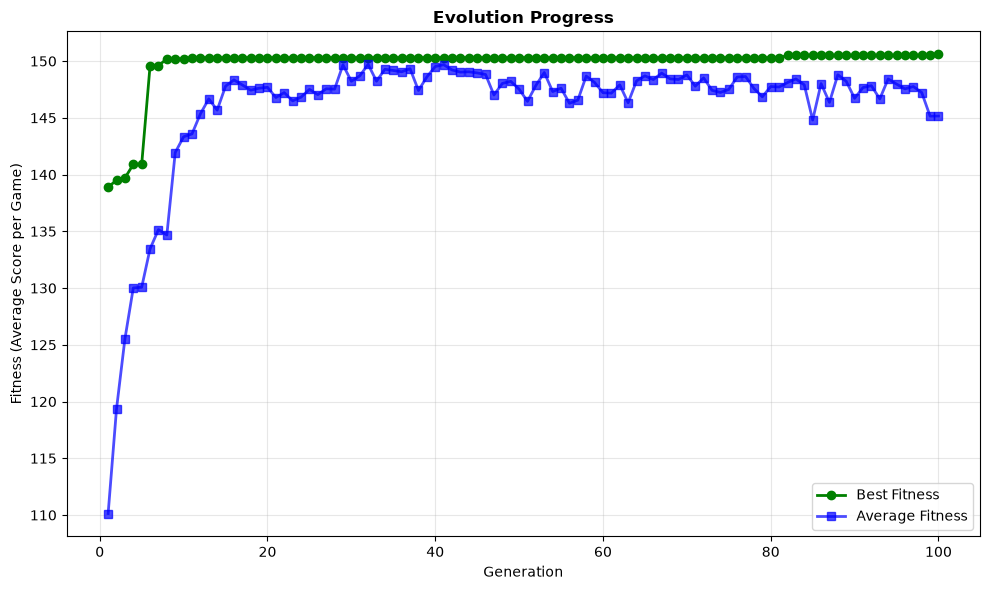


🎉 Your evolved agent's final genes:
   [1.0, 0.9933838931546759, 0.00807020588693974, 0.8526232480710652, 1.0, 0.07536124566424567]


In [ ]:

# ============================================================================
# PART 4: RUN EVOLUTION! 
# ============================================================================

print("\n" + "="*70)
print("🚀 TIME TO EVOLVE YOUR AGENT!")
print("="*70)

# TODO: Experiment with these parameters to find the best agent!
my_evolved_agent = evolve(
    generations=100,       # Try: 50, 100, 250
    pop_size=30,         # Try: 15, 20, 30
    opponents=opponent_pool,
    mutation_rate=0.15,  # I added 0.15
    elitism=2            # Keep top 2 agents each generation
)

print(f"\n🎉 Your evolved agent's final genes:")
print(f"   {my_evolved_agent.genes}")



In [12]:
# ============================================================================
# PART 5: TEST YOUR AGENT
# ============================================================================

print("\n" + "="*70)
print("⚔️  TESTING YOUR AGENT AGAINST HAND-CODED OPPONENTS")
print("="*70 + "\n")

# These opponents match the Benchmark Analysis table
benchmark_opponents = [
    AlwaysInvestAgent(),
    AlwaysUndercutAgent(),
    TitForTatAgent(),
    GrimTriggerAgent(),
    PavlovAgent(),
    TitForTwoTatsAgent(),
    GenerousTitForTatAgent(),
    AdaptiveAgent(),
    RandomAgent(0.7),
    RandomAgent(0.3)
]

wins = 0
losses = 0
ties = 0

for opponent in benchmark_opponents:
    game = Game(my_evolved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()

    if my_score > opp_score:
        result = "✅ WON"
        wins += 1
    elif my_score < opp_score:
        result = "❌ LOST"
        losses += 1
    else:
        result = "🤝 TIED"
        ties += 1

    print(
        f"vs {opponent.name:25s}: "
        f"{my_score:3d} - {opp_score:3d}  {result}"
    )

print(f"\n📊 Record: {wins} wins, {losses} losses, {ties} ties")

win_rate = wins / len(benchmark_opponents) * 100
print(f"🎯 Win Rate: {win_rate:.1f}%")


⚔️  TESTING YOUR AGENT AGAINST HAND-CODED OPPONENTS

vs Always Invest            : 300 - 300  🤝 TIED
vs Always Undercut          :  14 - 444  ❌ LOST
vs Tit-for-Tat              : 300 - 300  🤝 TIED
vs Grim Trigger             : 300 - 300  🤝 TIED
vs Pavlov                   : 282 - 307  ❌ LOST
vs Tit-for-Two-Tats         : 300 - 300  🤝 TIED
vs Generous Tit-for-Tat     : 299 - 299  🤝 TIED
vs Adaptive                 : 300 - 300  🤝 TIED
vs Random (0.7)             : 207 - 362  ❌ LOST
vs Random (0.3)             : 118 - 368  ❌ LOST

📊 Record: 0 wins, 4 losses, 6 ties
🎯 Win Rate: 0.0%


# Unit 5 Part 2: Benchmark Analysis

**After running your initial evolution and benchmark tests, answer these questions.**

---

## Performance Summary

Fill in your benchmark results:

| Opponent | Result (W/L/T) | Your Score | Opp Score |
|----------|----------------|------------|-----------|
| Always Invest | T | 300 | 300 |
| Always Undercut | L | 14 | 444 |
| Tit-for-Tat | T | 300 | 300 |
| Grim Trigger | T | 300 | 300 |
| Pavlov | L | 282 | 307 |
| Tit-for-Two-Tats | T | 300 | 300 |
| Generous Tit-for-Tat | T | 299 | 299 |
| Adaptive | T | 300 | 300 |
| Random (0.7) | L | 207 | 362 |
| Random (0.3) | L | 118 | 368 |
| **Total** | **0 W / 4 L / 6 T** | **2,420** | **3,280** |

---

## Analysis Questions

### 1. What was your agent's worst loss (greatest point differential) and why?
(Write 3-5 sentences explaining what happened and why)

My agent's worst loss was against Always Undercut, where it lost 14 to 444, a difference of 430 points. Its genes made it extremely cooperative and forgiving, while its probability of retaliating was only about 0.8%. Because Always Undercut never changed its behavior, it continued earning five points whenever my agent invested. My agent failed to recognize that continued cooperation was no longer useful against that opponent.

---

### 2. What pattern do you see in wins vs. losses?

(Which types of opponents does your agent beat/lose to? What do those agent types have in common?)

My agent tied with opponents that usually cooperated or responded to cooperation, including Always Invest, Tit-for-Tat, Grim Trigger, and Adaptive. It lost to opponents that undercut regularly or behaved less predictably, such as Always Undercut and the two Random agents. This shows that its cooperative strategy worked when cooperation was returned, but it did not protect itself well when the opponent repeatedly took advantage of it.

---

### 3. What would make an agent more competitive?

(What specific changes would you make? Why would these help? Think about how to outsmart the agents you're currently losing to)

I would make the agent use its retaliation threshold to identify opponents that repeatedly undercut instead of continuing to forgive them. It should respond strongly to a consistent pattern of undercutting while still forgiving an isolated action that could be a mistake or noise. This would help it defend itself against aggressive opponents without losing the cooperation that allowed it to tie with friendly strategies.


---

**Next:** Proceed to Part 3 to implement your improvements!

In [13]:
# ============================================================================
# PART 6: IMPROVE YOUR AGENT'S ACTION TAKING STRATEGY
# ============================================================================

class ImprovedEvolvableAgent(Agent):
    """
    Strategy controlled by eight genes.

    Gene[0] - Initial cooperation
    Gene[1] - Cooperation response
    Gene[2] - Retaliation strength
    Gene[3] - Forgiveness
    Gene[4] - Memory length
    Gene[5] - Retaliation threshold
    Gene[6] - Tolerance for repeated undercutting
    Gene[7] - Willingness to rebuild cooperation
    """

    def __init__(self, genes=None, name="Improved Agent"):
        if genes is None:
            genes = [random.random() for _ in range(8)]

        self.genes = genes
        description = f"Genes: [{', '.join(f'{g:.2f}' for g in genes)}]"
        super().__init__(name, description)

    def choose_action(self) -> bool:
        # Establish cooperation during the opening rounds
        if self.round_num < 3:
            return random.random() < self.genes[0]

        # Review a recent section of the opponent's history
        memory_length = 3 + int(self.genes[4] * 9)
        recent_history = self.history[-memory_length:]

        cooperation_rate = sum(recent_history) / len(recent_history)
        defection_rate = 1.0 - cooperation_rate

        # Count consecutive undercuts
        defection_streak = 0
        for action in reversed(recent_history):
            if action == UNDERCUT:
                defection_streak += 1
            else:
                break

        streak_limit = 2 + int(self.genes[6] * 3)

        # Stop forgiving an opponent that keeps undercutting
        if defection_streak >= streak_limit:
            return UNDERCUT

        # Try to rebuild cooperation when the opponent changes behavior
        if (
            len(self.history) >= 2
            and self.history[-2] == UNDERCUT
            and self.history[-1] == INVEST
        ):
            if random.random() < self.genes[7]:
                return INVEST

        # Cooperate with an opponent that has been consistently cooperative
        if defection_rate == 0:
            return random.random() < self.genes[1]

        retaliation_threshold = 0.15 + (self.genes[5] * 0.55)

        # Respond when undercutting becomes a pattern
        if defection_rate >= retaliation_threshold:
            if random.random() < self.genes[2]:
                return UNDERCUT

            if random.random() < self.genes[3]:
                return INVEST

            return UNDERCUT

        # Decide whether to forgive an isolated undercut
        if self.history[-1] == UNDERCUT:
            return random.random() < self.genes[3]

        return random.random() < self.genes[1]

    def save_to_file(self, filename):
        """Save the agent's name and genes."""
        data = {
            "name": self.name,
            "genes": self.genes,
            "description": self.description
        }

        with open(filename, "w") as file:
            json.dump(data, file, indent=2)

        print(f"✅ Agent saved to {filename}")


🔧 EVOLVING YOUR IMPROVED AGENT!

Training improved agent against 13 opponents.

🧬 EVOLUTION STARTING (Improved Agent)
Population: 30 | Generations: 100 | Mutation: 0.15
Opponents: 13 | Elitism: 2

Gen   1/100: Best=129.00 | Avg=106.49 | Genes=['0.84', '0.96', '0.58', '0.64', '0.77', '0.27', '0.14', '0.47']
Gen   2/100: Best=132.23 | Avg=114.71 | Genes=['0.82', '0.98', '0.45', '0.99', '0.48', '0.93', '0.80', '0.37']
Gen   3/100: Best=133.08 | Avg=122.60 | Genes=['0.85', '0.96', '0.58', '0.78', '0.96', '0.40', '0.80', '0.37']
Gen   4/100: Best=135.31 | Avg=124.74 | Genes=['0.84', '0.96', '0.58', '0.78', '0.96', '0.61', '0.39', '0.26']
Gen   5/100: Best=135.69 | Avg=125.77 | Genes=['0.84', '0.96', '0.58', '0.78', '0.96', '0.61', '0.14', '0.40']
Gen   6/100: Best=135.69 | Avg=126.30 | Genes=['1.00', '1.00', '0.58', '0.78', '0.96', '0.23', '0.39', '0.24']
Gen   7/100: Best=137.00 | Avg=128.51 | Genes=['1.00', '1.00', '0.58', '0.58', '0.96', '0.23', '0.39', '0.37']
Gen   8/100: Best=137.23 

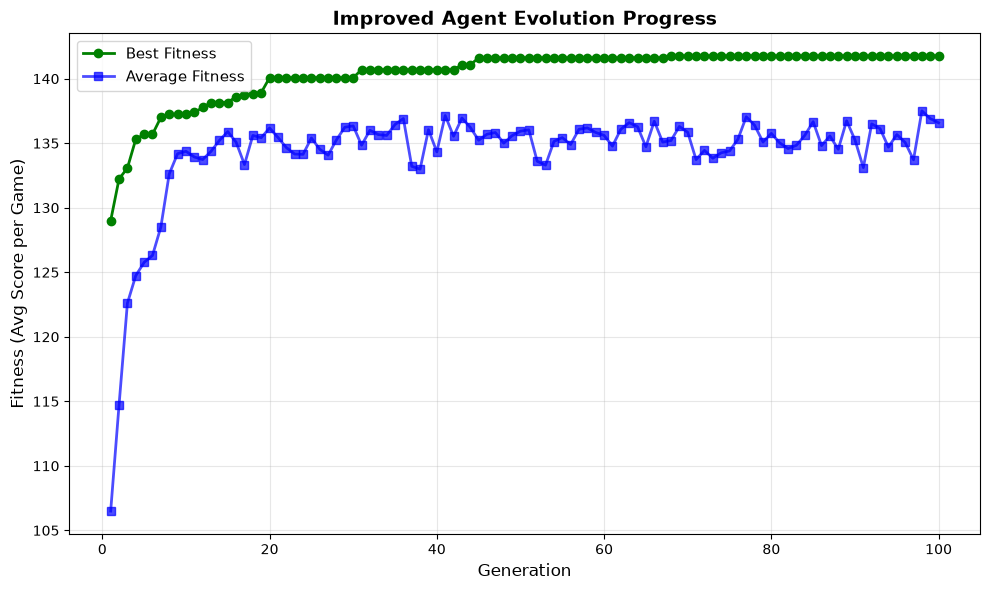


🎉 Your improved agent's final genes:
   [1.0, 1.0, 0.824421366268778, 0.0, 0.6326476140264558, 0.3448205781863124, 0.0, 0.0]


In [15]:
# ============================================================================
# PART 7: EVOLVE YOUR IMPROVED AGENT
# ============================================================================

print("\n" + "="*70)
print("🔧 EVOLVING YOUR IMPROVED AGENT!")
print("="*70)


def evolve_improved(
    generations=25,
    pop_size=20,
    opponents=None,
    mutation_rate=0.15,
    elitism=2
):
    """
    Evolve a population of ImprovedEvolvableAgent objects.
    """
    if opponents is None:
        opponents = opponent_pool

    print("\n🧬 EVOLUTION STARTING (Improved Agent)")
    print("="*70)
    print(
        f"Population: {pop_size} | "
        f"Generations: {generations} | "
        f"Mutation: {mutation_rate}"
    )
    print(f"Opponents: {len(opponents)} | Elitism: {elitism}")
    print("="*70 + "\n")

    best_fitness_history = []
    avg_fitness_history = []

    population = [
        ImprovedEvolvableAgent(name=f"Agent_{i}")
        for i in range(pop_size)
    ]

    best_overall_agent = None
    best_overall_fitness = -float("inf")

    for gen in range(generations):
        fitnesses = []

        for agent in population:
            fitness = evaluate_fitness(
                agent,
                opponents,
                num_rounds=50
            )
            fitnesses.append(fitness)

        best_fitness = max(fitnesses)
        avg_fitness = sum(fitnesses) / len(fitnesses)
        best_idx = fitnesses.index(best_fitness)

        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            best_overall_agent = ImprovedEvolvableAgent(
                genes=population[best_idx].genes.copy()
            )

        best_fitness_history.append(best_overall_fitness)
        avg_fitness_history.append(avg_fitness)

        print(
            f"Gen {gen + 1:3d}/{generations}: "
            f"Best={best_overall_fitness:6.2f} | "
            f"Avg={avg_fitness:6.2f} | "
            f"Genes={[f'{g:.2f}' for g in population[best_idx].genes]}"
        )

        if gen < generations - 1:
            sorted_indices = sorted(
                range(len(fitnesses)),
                key=lambda i: fitnesses[i],
                reverse=True
            )

            next_population = []

            # Keep the strongest agents
            for i in range(elitism):
                elite_genes = population[
                    sorted_indices[i]
                ].genes.copy()

                next_population.append(
                    ImprovedEvolvableAgent(genes=elite_genes)
                )

            selected = tournament_selection(
                population,
                fitnesses
            )

            while len(next_population) < pop_size:
                parent1, parent2 = random.sample(selected, 2)

                child = crossover_and_mutate(
                    parent1,
                    parent2,
                    mutation_rate
                )

                next_population.append(
                    ImprovedEvolvableAgent(
                        genes=child.genes.copy()
                    )
                )

            population = next_population

    print("\n" + "="*70)
    print("✅ EVOLUTION COMPLETE!")
    print(f"🏆 Best fitness achieved: {best_overall_fitness:.2f}")
    print("="*70 + "\n")

    plt.figure(figsize=(10, 6))

    plt.plot(
        range(1, generations + 1),
        best_fitness_history,
        label="Best Fitness",
        linewidth=2,
        color="green",
        marker="o"
    )

    plt.plot(
        range(1, generations + 1),
        avg_fitness_history,
        label="Average Fitness",
        linewidth=2,
        color="blue",
        marker="s",
        alpha=0.7
    )

    plt.xlabel("Generation", fontsize=12)
    plt.ylabel("Fitness (Avg Score per Game)", fontsize=12)
    plt.title(
        "Improved Agent Evolution Progress",
        fontsize=14,
        fontweight="bold"
    )
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return best_overall_agent


# Add strategies that exposed weaknesses in the original agent
extra_training_opponents = [
    AlwaysUndercutAgent(),
    RandomAgent(0.7),
    RandomAgent(0.3)
]

# Avoid duplicate opponents if Part 2 selected one of them
improved_training_pool = list(opponent_pool)
training_names = {
    opponent.name for opponent in improved_training_pool
}

for opponent in extra_training_opponents:
    if opponent.name not in training_names:
        improved_training_pool.append(opponent)
        training_names.add(opponent.name)

print(
    f"\nTraining improved agent against "
    f"{len(improved_training_pool)} opponents."
)

my_improved_agent = evolve_improved(
    generations=100,
    pop_size=30,
    opponents=improved_training_pool,
    mutation_rate=0.15,
    elitism=2
)

print("\n🎉 Your improved agent's final genes:")
print(f"   {my_improved_agent.genes}")

In [16]:
# ============================================================================
# PART 8.1: COMPARE ORIGINAL VS IMPROVED
# ============================================================================

print("\n" + "="*70)
print("📊 COMPARISON: Original vs Improved Agent")
print("="*70 + "\n")


# Test the original agent
print("ORIGINAL AGENT:")

wins_orig = 0
losses_orig = 0
ties_orig = 0
score_orig = 0
opponent_score_orig = 0

for opponent in opponent_pool:
    game = Game(
        my_evolved_agent,
        opponent,
        num_rounds=100
    )

    my_score, opp_score = game.play()

    score_orig += my_score
    opponent_score_orig += opp_score

    if my_score > opp_score:
        wins_orig += 1
        result = "✅ WON"
    elif my_score < opp_score:
        losses_orig += 1
        result = "❌ LOST"
    else:
        ties_orig += 1
        result = "🤝 TIED"

    print(
        f"vs {opponent.name:25s}: "
        f"{my_score:3d} - {opp_score:3d}  {result}"
    )

original_win_rate = wins_orig / len(opponent_pool) * 100

print(
    f"\nOriginal Record: "
    f"{wins_orig} wins, "
    f"{losses_orig} losses, "
    f"{ties_orig} ties"
)

print(f"Original Win Rate: {original_win_rate:.1f}%")
print(
    f"Original Total Score: "
    f"{score_orig} - {opponent_score_orig}"
)


print("\n" + "-"*70 + "\n")


# Test the improved agent against the same opponents
print("IMPROVED AGENT:")

wins_improved = 0
losses_improved = 0
ties_improved = 0
score_improved = 0
opponent_score_improved = 0

for opponent in opponent_pool:
    game = Game(
        my_improved_agent,
        opponent,
        num_rounds=100
    )

    my_score, opp_score = game.play()

    score_improved += my_score
    opponent_score_improved += opp_score

    if my_score > opp_score:
        wins_improved += 1
        result = "✅ WON"
    elif my_score < opp_score:
        losses_improved += 1
        result = "❌ LOST"
    else:
        ties_improved += 1
        result = "🤝 TIED"

    print(
        f"vs {opponent.name:25s}: "
        f"{my_score:3d} - {opp_score:3d}  {result}"
    )

improved_win_rate = wins_improved / len(opponent_pool) * 100

print(
    f"\nImproved Record: "
    f"{wins_improved} wins, "
    f"{losses_improved} losses, "
    f"{ties_improved} ties"
)

print(f"Improved Win Rate: {improved_win_rate:.1f}%")
print(
    f"Improved Total Score: "
    f"{score_improved} - {opponent_score_improved}"
)


print("\n" + "="*70)

win_change = wins_improved - wins_orig
score_change = score_improved - score_orig

print(f"📈 CHANGE IN WINS: {win_change:+d}")
print(f"📈 CHANGE IN TOTAL SCORE: {score_change:+d}")
print("="*70)


# ============================================================================
# GENERALIZATION TEST: FULL OPPONENT POOL
# ============================================================================

print("\n" + "="*70)
print("🌍 GENERALIZATION TEST: Against ALL Possible Opponents")
print("="*70 + "\n")

print("Testing the improved agent against the full opponent library.")
print("This includes opponents it did not encounter during training.\n")

training_names = {
    opponent.name for opponent in improved_training_pool
}

wins_full = 0
losses_full = 0
ties_full = 0

unseen_wins = 0
unseen_losses = 0
unseen_ties = 0
unseen_count = 0

for opponent in full_opponent_pool:
    game = Game(
        my_improved_agent,
        opponent,
        num_rounds=100
    )

    my_score, opp_score = game.play()
    was_trained = opponent.name in training_names

    if my_score > opp_score:
        result = "✅ WON"
        wins_full += 1

        if not was_trained:
            unseen_wins += 1

    elif my_score < opp_score:
        result = "❌ LOST"
        losses_full += 1

        if not was_trained:
            unseen_losses += 1

    else:
        result = "🤝 TIED"
        ties_full += 1

        if not was_trained:
            unseen_ties += 1

    if was_trained:
        marker = "📚"
    else:
        marker = "🆕"
        unseen_count += 1

    print(
        f"{marker} vs {opponent.name:25s}: "
        f"{my_score:3d} - {opp_score:3d}  {result}"
    )

print(
    f"\n📊 Results against all "
    f"{len(full_opponent_pool)} opponents:"
)

print(
    f"   Wins: {wins_full} | "
    f"Losses: {losses_full} | "
    f"Ties: {ties_full}"
)

full_win_rate = (
    wins_full / len(full_opponent_pool) * 100
)

print(f"   Win Rate: {full_win_rate:.1f}%")

print(
    f"\n📊 Results against the "
    f"{unseen_count} unseen opponents:"
)

print(
    f"   Wins: {unseen_wins} | "
    f"Losses: {unseen_losses} | "
    f"Ties: {unseen_ties}"
)

if unseen_count > 0:
    unseen_win_rate = unseen_wins / unseen_count * 100
    print(f"   Win Rate: {unseen_win_rate:.1f}%")

print("\n💡 Legend: 📚 = Training opponent | 🆕 = Unseen opponent")
print("="*70)


📊 COMPARISON: Original vs Improved Agent

ORIGINAL AGENT:
vs Suspicious Tit-for-Tat   : 295 - 300  ❌ LOST
vs Soft Majority            : 302 - 297  ✅ WON
vs Hard Majority            : 302 - 297  ✅ WON
vs Pavlov                   : 300 - 300  🤝 TIED
vs Gradual                  : 300 - 300  🤝 TIED
vs Tit-for-Tat              : 300 - 300  🤝 TIED
vs Always Invest            : 304 - 294  ✅ WON
vs Generous Tit-for-Tat     : 298 - 298  🤝 TIED
vs Tit-for-Two-Tats         : 300 - 300  🤝 TIED
vs Grim Trigger             : 300 - 300  🤝 TIED

Original Record: 3 wins, 1 losses, 6 ties
Original Win Rate: 30.0%
Original Total Score: 3001 - 2986

----------------------------------------------------------------------

IMPROVED AGENT:
vs Suspicious Tit-for-Tat   : 297 - 302  ❌ LOST
vs Soft Majority            : 300 - 300  🤝 TIED
vs Hard Majority            : 300 - 300  🤝 TIED
vs Pavlov                   : 300 - 300  🤝 TIED
vs Gradual                  : 300 - 300  🤝 TIED
vs Tit-for-Tat              : 300

In [17]:
# ============================================================================
# PART 8.2: COMPETE IN YOUR FINAL TOURNAMENT
# ============================================================================

print("\n" + "="*70)
print("🏆 FULL TOURNAMENT COMPARISON")
print("="*70 + "\n")


# Run the original-agent tournament
print("Running tournament with ORIGINAL agent...")

random.seed(2026)

original_tournament_agents = (
    full_opponent_pool + [my_evolved_agent]
)

original_tournament = Tournament(
    original_tournament_agents,
    rounds_per_match=100,
    num_tournaments=1
)

original_tournament.run_tournament()


# Run the improved-agent tournament
print("\n" + "-"*70)
print("\nRunning tournament with IMPROVED agent...")

random.seed(2026)

improved_tournament_agents = (
    full_opponent_pool + [my_improved_agent]
)

improved_tournament = Tournament(
    improved_tournament_agents,
    rounds_per_match=100,
    num_tournaments=1
)

improved_tournament.run_tournament()


# Compare the rankings
print("\n" + "="*70)
print("📊 TOURNAMENT RESULTS COMPARISON")
print("="*70 + "\n")

original_rankings = original_tournament.get_rankings()
improved_rankings = improved_tournament.get_rankings()

original_rank = None
improved_rank = None
original_score = None
improved_score = None

for rank, (name, score) in enumerate(
    original_rankings,
    start=1
):
    if name == my_evolved_agent.name:
        original_rank = rank
        original_score = score

for rank, (name, score) in enumerate(
    improved_rankings,
    start=1
):
    if name == my_improved_agent.name:
        improved_rank = rank
        improved_score = score


print("ORIGINAL AGENT:")
print(
    f"  Rank: {original_rank} / "
    f"{len(original_rankings)}"
)
print(f"  Total Score: {original_score:,}")


print("\nIMPROVED AGENT:")
print(
    f"  Rank: {improved_rank} / "
    f"{len(improved_rankings)}"
)
print(f"  Total Score: {improved_score:,}")


rank_change = original_rank - improved_rank
score_change = improved_score - original_score
percent_change = (
    score_change / original_score * 100
)

if improved_rank < original_rank:
    rank_symbol = "⬆️"
elif improved_rank > original_rank:
    rank_symbol = "⬇️"
else:
    rank_symbol = "➡️"


print("\nIMPROVEMENT:")
print(
    f"  Rank Change: {rank_change:+d} "
    f"positions {rank_symbol}"
)
print(
    f"  Score Change: {score_change:+,} points "
    f"({percent_change:+.1f}%)"
)
print("="*70)


# Show the improved tournament leaderboard
print("\n🏆 IMPROVED AGENT TOURNAMENT LEADERBOARD:")
print("="*60)

for rank, (name, score) in enumerate(
    improved_rankings,
    start=1
):
    if rank == 1:
        emoji = "🥇"
    elif rank == 2:
        emoji = "🥈"
    elif rank == 3:
        emoji = "🥉"
    else:
        emoji = "  "

    if name == my_improved_agent.name:
        marker = " ⭐ YOUR AGENT"
    else:
        marker = ""

    print(
        f"{emoji} {rank:2d}. "
        f"{name:25s}: "
        f"{score:,} points{marker}"
    )


🏆 FULL TOURNAMENT COMPARISON

Running tournament with ORIGINAL agent...
Running 1 tournament(s) with 19 agents...
Match 1/342: Always Invest vs Tit-for-Tat
Match 2/342: Always Invest vs Grim Trigger
Match 3/342: Always Invest vs Pavlov
Match 4/342: Always Invest vs Tit-for-Two-Tats
Match 5/342: Always Invest vs Generous Tit-for-Tat
Match 6/342: Always Invest vs Adaptive
Match 7/342: Always Invest vs Always Undercut
Match 8/342: Always Invest vs Suspicious Tit-for-Tat
Match 9/342: Always Invest vs Gradual
Match 10/342: Always Invest vs Prober
Match 11/342: Always Invest vs Hard Majority
Match 12/342: Always Invest vs Soft Majority
Match 13/342: Always Invest vs Random (0.9)
Match 14/342: Always Invest vs Random (0.7)
Match 15/342: Always Invest vs Random (0.5)
Match 16/342: Always Invest vs Random (0.3)
Match 17/342: Always Invest vs Random (0.1)
Match 18/342: Always Invest vs Evolved Agent
Match 19/342: Tit-for-Tat vs Always Invest
Match 20/342: Tit-for-Tat vs Grim Trigger
Match 21/34

In [18]:
# ============================================================================
# PART 9: EXPORT COMPLETE AGENT AS PYTHON MODULE
# ============================================================================

import inspect
import importlib.util
import random
import textwrap
from datetime import datetime
from pathlib import Path


def export_complete_agent(
    agent,
    student_name,
    generations=100,
    final_fitness=None
):
    """
    Export the evolved genes and decision logic as a Python module.
    """

    # Create a valid Python class name
    clean_name = "".join(
        character
        for character in student_name
        if character.isalnum()
    )

    if not clean_name:
        clean_name = "Student"

    if clean_name[0].isdigit():
        clean_name = "Student" + clean_name

    # Copy the decision method with the correct class indentation
    decision_source = inspect.getsource(agent.choose_action)
    decision_code = textwrap.indent(
        textwrap.dedent(decision_source),
        "    "
    )

    # Record the actual improved training opponents
    try:
        opponent_names = [
            opponent.name
            for opponent in improved_training_pool
        ]

        opponent_info = (
            "Trained against: "
            + ", ".join(opponent_names)
        )
    except NameError:
        opponent_info = "Training opponent information unavailable"

    fitness_text = (
        f"{final_fitness:.2f}"
        if final_fitness is not None
        else "N/A"
    )

    code = f'''#!/usr/bin/env python
"""
Tournament Agent: {agent.name}
Student: {student_name}
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Evolution Details:
- Generations: {generations}
- Final Fitness: {fitness_text}
- {opponent_info}

Strategy: {agent.description}
"""

from agents import Agent, INVEST, UNDERCUT
import random


class {clean_name}Agent(Agent):
    """
    {agent.name}

    {agent.description}

    Evolved Genes: {agent.genes}
    """

    def __init__(self):
        self.genes = {agent.genes!r}
        self.student_name = {student_name!r}

        super().__init__(
            name={agent.name!r},
            description={agent.description!r}
        )

{decision_code}


def get_agent():
    """Return an instance for tournament use."""
    return {clean_name}Agent()


if __name__ == "__main__":
    agent = get_agent()
    print(f"Agent loaded successfully: {{agent.name}}")
    print(f"Genes: {{agent.genes}}")
    print(f"Description: {{agent.description}}")
'''

    filename = f"{clean_name.lower()}_tournament_agent.py"

    with open(filename, "w", encoding="utf-8") as file:
        file.write(code)

    # Check the exported file for syntax errors
    compile(code, filename, "exec")

    full_path = Path(filename).resolve()

    print("="*70)
    print("✅ COMPLETE TOURNAMENT AGENT EXPORTED!")
    print("="*70)
    print(f"📄 File: {filename}")
    print(f"📍 Location: {full_path}")
    print(f"🏷️  Class: {clean_name}Agent")
    print(f"🧬 Genes: {agent.genes}")
    print()
    print("📦 Included:")
    print("   ✓ Eight evolved gene values")
    print("   ✓ Complete decision logic")
    print("   ✓ Student and training information")
    print("   ✓ Tournament loading function")
    print("="*70)

    return filename


# ============================================================================
# EXPORT THE IMPROVED AGENT
# ============================================================================

print("\n" + "="*70)
print("💾 EXPORTING YOUR TOURNAMENT AGENT")
print("="*70 + "\n")

STUDENT_NAME = "Christelle Jean"

my_improved_agent.name = "Two-Strike Guard"
my_improved_agent.description = ( "Starts by investing but undercuts after two defections in a row."
)

print(f"Agent Name: {my_improved_agent.name}")
print(f"Description: {my_improved_agent.description}")
print(
    f"Genes: "
    f"{[f'{gene:.2f}' for gene in my_improved_agent.genes]}\n"
)

exported_file = export_complete_agent(
    agent=my_improved_agent,
    student_name=STUDENT_NAME,
    generations=100,
    final_fitness=141.77
)


# Load the exported file to make sure it works
export_path = Path(exported_file).resolve()

module_spec = importlib.util.spec_from_file_location(
    "exported_tournament_agent",
    export_path
)

exported_module = importlib.util.module_from_spec(
    module_spec
)

module_spec.loader.exec_module(exported_module)
test_agent = exported_module.get_agent()

print("\n🧪 EXPORT TEST:")
print(f"   Loaded Agent: {test_agent.name}")
print(f"   Gene Count: {len(test_agent.genes)}")

if test_agent.genes == my_improved_agent.genes:
    print("   Gene Check: Passed")
else:
    print("   Gene Check: Failed")

print("\n✨ Your agent is ready for the Unit 6 tournament.")


💾 EXPORTING YOUR TOURNAMENT AGENT

Agent Name: Two-Strike Guard
Description: Starts by investing but undercuts after two defections in a row.
Genes: ['1.00', '1.00', '0.82', '0.00', '0.63', '0.34', '0.00', '0.00']

✅ COMPLETE TOURNAMENT AGENT EXPORTED!
📄 File: christellejean_tournament_agent.py
📍 Location: C:\Users\brond\Documents\applied-ai-4-chris-jean\Act 2\christellejean_tournament_agent.py
🏷️  Class: ChristelleJeanAgent
🧬 Genes: [1.0, 1.0, 0.824421366268778, 0.0, 0.6326476140264558, 0.3448205781863124, 0.0, 0.0]

📦 Included:
   ✓ Eight evolved gene values
   ✓ Complete decision logic
   ✓ Student and training information
   ✓ Tournament loading function

🧪 EXPORT TEST:
   Loaded Agent: Two-Strike Guard
   Gene Count: 8
   Gene Check: Passed

✨ Your agent is ready for the Unit 6 tournament.


## Post-Evolution Reflection Questions

### 1. Generalization Analysis
- Compare your agent's performance on training opponents (📚) vs. unseen opponents (🆕)
- Did your agent generalize well or overfit to the training set?
- What does this suggest about evolving against a random sample vs. fixed opponents?

My improved agent recorded 2 wins, 2 losses, and 9 ties against its 13 training opponents, compared with 3 wins, 1 loss, and 1 tie against the five unseen opponents. This 60% win rate on unseen strategies suggests that the agent generalized well instead of only memorizing its training set. I started with the random sample of 10 opponents and added three strategies that exposed the original agent’s weaknesses, so the results show that combining a varied sample with a few targeted opponents produced better preparation than repeatedly training against one fixed group.


### 2. Tournament Performance
- What was your agent's final tournament rank? _____ out of _____
- What was your agent's total score? _____
- Look at agents that ranked above and below you - what strategies do they use?

My agent finished 6th out of 19 with 4,733 points, improving from the original agent’s 14th-place finish and 4,081 points. The agents above mine mainly used conditional cooperation: Gradual increased its punishment, Grim Trigger stopped cooperating after one betrayal, Tit-for-Tat copied the previous move, Generous Tit-for-Tat sometimes forgave, and Hard Majority considered the opponent’s overall history. Below mine, Soft Majority was more cooperative, Pavlov used a win-stay-lose-shift approach, Adaptive followed the opponent’s cooperation rate, and the random or Always Undercut strategies did not maintain the same balance between cooperation and self-protection.


### 3. Strategy Analysis
Look at your evolved genes: [____________________]

- In plain English, what strategy did your agent evolve?
- Does it cooperate with cooperators? Does it punish defectors?
- Why do you think evolution discovered this particular strategy?

My evolved genes were [1.0, 1.0, 0.824421366268778, 0.0, 0.6326476140264558, 0.3448205781863124, 0.0, 0.0]. In plain English, Two-Strike Guard begins cooperatively, continues cooperating with consistent cooperators, remembers about eight recent rounds, and punishes defectors by undercutting when defections reach about one-third of that history or happen twice in a row. I think evolution discovered this balance because mutual investment provides steady profits, while retaliation prevents aggressive opponents from repeatedly earning five points by exploiting its cooperation.


### 4. Trade-offs
Every strategy has strengths and weaknesses.

- Which types of opponents does your agent beat?
- Which types beat your agent?
- If you could redesign your agent for Unit 6, what would you change?

My agent performed especially well against mixed and unpredictable strategies, defeating all five Random agents in the full-pool test, while it usually tied with consistently cooperative or reciprocal opponents. Always Undercut, Suspicious Tit-for-Tat, and Prober defeated it because they gained an early advantage while it was still beginning with three cooperative moves. For Unit 6, I would shorten the automatic cooperative opening and add a small recovery rule so it could react earlier to exploitation without becoming trapped in permanent retaliation after a mistake. Also, I was thinking about adding a gene that would let the agent adjust its retaliation threshold during a game instead of reacting the same way to every opponent.


### 5. The Environment Matters
- You evolved against a random sample of 10 opponents
- The tournament included all 19 opponents
- Unit 6 will include 30+ student agents with unpredictable strategies
- How might your agent perform in that different environment?

Although the instructions began with a random sample of 10 opponents, I expanded the improved training group to 13 after the first benchmark revealed weaknesses against permanent and unpredictable undercutting. Finishing 6th in the 19-agent tournament and going 3-1-1 against unseen opponents gives me confidence that the strategy can remain competitive against the 30 or more student agents in Unit 6. However, another student could exploit its predictable opening or lack of forgiveness, so performance will depend on whether the larger tournament rewards stable cooperation or contains many agents designed to test and manipulate fixed patterns.